In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pickle
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from scipy.stats import binned_statistic_2d

sys.path.insert(0, str((Path("..") / "src" / "utils").resolve()))
import micron_comparison
import visium_hd
from border_fit import ALL_SAMPLES

from bosperrus import (
    delaunay_edges, compute_centrality_measures, distance_to_convex_hull,
    Flow, ConstantFit, PiecewiseLinearFit, FIT_PALETTE, plot_fit,
)

plt.rcParams['svg.fonttype'] = 'none'

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/.pixi/envs/default/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## MIBI-TOF

Delaunay graph on cell centroids: closeness centrality (row 1) and distance to convex hull (row 2).

In [3]:
with open("../mibitof_coords/coords.pickle", "rb") as f:
    mibitof_datasets = pickle.load(f)

mibitof_dataset = "TNBC_mibitof:p14_labeledcellData.tiff"
mibitof_coords = mibitof_datasets[mibitof_dataset]
mibitof_coords = mibitof_coords[(mibitof_coords[:, 0] < 1500) & (mibitof_coords[:, 1] < 1500)]
mibitof_subset = mibitof_coords / (np.max(mibitof_coords, axis=0) - np.min(mibitof_coords, axis=0))

G = nx.Graph()
G.add_nodes_from(range(len(mibitof_subset)))
for n in G.nodes:
    G.nodes[n]["pos"] = mibitof_subset[n]
mibitof_edges = delaunay_edges(mibitof_subset)
G.add_edges_from(mibitof_edges)

closeness = pd.DataFrame(compute_centrality_measures(mibitof_edges, len(mibitof_subset), measures=["closeness"]))["closeness"].values
mibitof_distance = distance_to_convex_hull(mibitof_subset)

mibitof_flow = Flow.from_distances_and_scores(
    distances=mibitof_distance, scores=pd.DataFrame({"closeness": closeness}),
)
mibitof_flow.flow(fits=[ConstantFit, PiecewiseLinearFit], baseline_fit_class=ConstantFit)
mibitof_fit = mibitof_flow.best_fits["closeness"]

## MICrONS

Connectome degree, plotted spatially (x-z view, row 1) and against distance
to the alpha-shape boundary (row 2). `micron_comparison.prepare_microns_data`
does the loading and the BOSPERRUS fit against alpha-shape distance
internally — see its docstring in `src/utils/` for details.

In [4]:
MICRONS_FN_MAT = "/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/data/reimann_data/microns_mm3_connectome.h5"
MICRONS_NBINS = 100

microns_data = micron_comparison.prepare_microns_data(
    MICRONS_FN_MAT, nbins=51, alpha=0.0001, reimann_thresh=0.05,
)
microns_xz = microns_data["M"].vertices[["x_nm", "z_nm"]]
microns_x, microns_z = microns_xz["x_nm"], microns_xz["z_nm"]
microns_degree = microns_data["scores"]["degree"]
microns_fit = microns_data["flow"].best_fits["degree"]

# average degree per 100x100 x-z bin, for the spatial-map panel
microns_degree_binned, microns_x_edges, microns_z_edges, _ = binned_statistic_2d(
    microns_x, microns_z, microns_degree, statistic="mean", bins=MICRONS_NBINS
)

/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/src/utils/micron_comparison.py:54: RuntimeWarning: invalid value encountered in divide
  C.add_vertex_property("outer_syn_fraction", outer_per_neuron / C.vertices["indegree"].values)
/home/woody/iwbn/iwbn007h/bosperrus/truncated_graphs/src/utils/micron_comparison.py:65: UserWarning: Alpha shape with alpha=0.0001 produced a MultiPolygon (2 disconnected fragments). This usually means alpha is too large: the boundary has been split into pieces, and distances will be measured to the nearest fragment rather than a single enclosing boundary. Consider reducing alpha and inspecting the result visually.
  alpha_distances = bosperrus.distance_to_alpha_shape(coords_xz, alpha=alpha).values


## Visium HD

Breast cancer (Fixed Frozen) sample: raw log1p total counts (row 1) and the
BOSPERRUS fit against distance to the nearest tissue-border spot (row 2).
`visium_hd.analyze_dataset` does its own internal `read_h5ad`, so the file
is read twice across this section; fine for exploratory use, not optimized
here.

In [5]:
visium_row = ALL_SAMPLES.set_index("name").loc["breast_cancer"]

adata = visium_hd.read_h5ad(visium_row["h5ad_path"])
visium_result = visium_hd.analyze_dataset(visium_row["h5ad_path"])
visium_component = visium_result[0]  # largest connected component
visium_fit = visium_component["fits"]["piecewise_linear"]
visium_d = visium_component["dist_to_border"]
visium_s = visium_component["log1p_total_counts"]

INFO     Creating graph using `None` transform and `1` libraries.                                                  


## Combined overview figure (2 rows × 3 columns)

Row 1: spatial maps, each colored by its measure (magma throughout). (0,0)
Delaunay graph on MIBI-TOF centroids, colored by closeness centrality. (0,1)
MICrONS connectome, x-z view colored by degree. (0,2) Visium HD (breast
cancer) scatter, colored by log1p total counts.

Row 2: the same three measures plotted against their respective distance
reference via `bosperrus.plot_fit` (2D histogram + fitted `PiecewiseLinearFit`
"elbow" curve, `bosperrus.FIT_PALETTE`-colored) -- MICrONS now plots the raw
per-neuron (degree, alpha-shape distance) pairs directly rather than reusing
row 1's spatially-binned means, since `plot_fit` does its own density
histogram. MICrONS reuses the fit `micron_comparison.prepare_microns_data`
already computed; MIBI-TOF and Visium HD each get their own
`Flow.flow(fits=[ConstantFit, PiecewiseLinearFit])` call here (MIBI-TOF
didn't have one at all before, Visium's came from `analyze_dataset`'s
per-component fits). (1,0) MIBI-TOF closeness vs. distance to convex hull.
(1,1) MICrONS degree vs. distance to alpha shape. (1,2) Visium log1p total
counts vs. distance to nearest tissue-border spot.

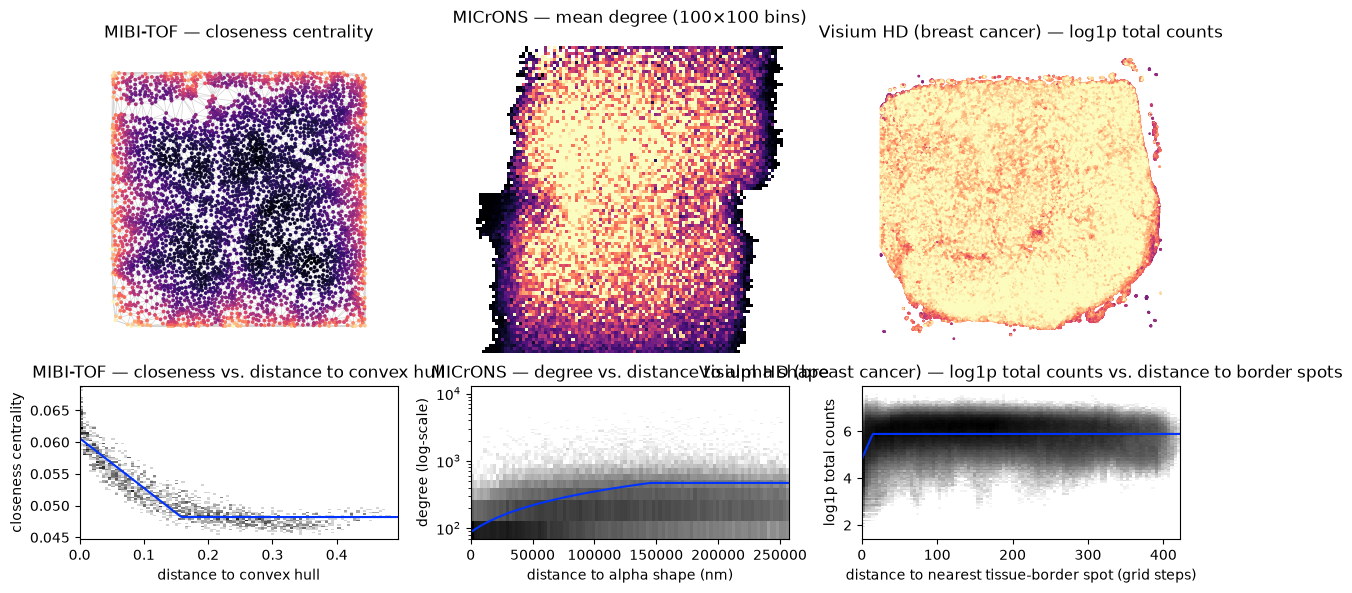

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(12, 6), height_ratios=[2, 1])
cmap = "magma"
fit_color = FIT_PALETTE["Piecewise Linear Fit"]
# --- Row 1: spatial maps, colored by the measure ---

# (0,0): Delaunay graph on MIBI-TOF centroids, colored by closeness centrality
pos = nx.get_node_attributes(G, "pos")
edges1 = nx.draw_networkx_edges(G, pos=pos, ax=axes[0, 0], edge_color="lightgray", width=0.5)
nodes1 = nx.draw_networkx_nodes(G, pos=pos, node_color=closeness, node_size=3, cmap=cmap, ax=axes[0, 0])
edges1.set_rasterized(True)
nodes1.set_rasterized(True)
axes[0, 0].set_title("MIBI-TOF — closeness centrality")
axes[0, 0].set_aspect("equal")
axes[0, 0].axis("off")
#plt.colorbar(nodes1, ax=axes[0, 0], fraction=0.046, pad=0.04)

# (0,1): MICrONS connectome, x-z view, mean degree per 100x100 bin
im2 = axes[0, 1].imshow(
    microns_degree_binned.T, origin="lower",
    extent=[microns_x_edges[0], microns_x_edges[-1], microns_z_edges[0], microns_z_edges[-1]],
    cmap=cmap, vmax=400, aspect="auto"
)
axes[0, 1].set_title(f"MICrONS — mean degree ({MICRONS_NBINS}×{MICRONS_NBINS} bins)")
axes[0, 1].set_box_aspect(1)
axes[0, 1].axis("off")
#plt.colorbar(im2, ax=axes[0, 1], fraction=0.046, pad=0.04)

# (0,2): Visium HD scatter, colored by log1p total counts
sc3 = axes[0, 2].scatter(adata.obs["array_col"], adata.obs["array_row"], c=adata.obs["log1p_total_counts"],
                          s=0.5, rasterized=True, vmin=0, vmax=6, cmap=cmap)
axes[0, 2].set_title("Visium HD (breast cancer) — log1p total counts")
axes[0, 2].set_aspect("equal")
axes[0, 2].invert_yaxis()
axes[0, 2].axis("off")
#plt.colorbar(sc3, ax=axes[0, 2], fraction=0.046, pad=0.04)

# --- Row 2: measure vs. distance, each via bosperrus.plot_fit (2D histogram + fitted PiecewiseLinearFit "elbow" curve) ---

# (1,0): MIBI-TOF closeness vs. distance to convex hull
plot_fit(axes[1, 0], mibitof_distance, closeness, mibitof_fit.predict, line_kwargs={"color": fit_color, "linewidth": 1.5})
axes[1, 0].set_title("MIBI-TOF — closeness vs. distance to convex hull")
axes[1, 0].set_xlabel("distance to convex hull")
axes[1, 0].set_ylabel("closeness centrality")

# (1,1): MICrONS degree vs. distance to alpha shape (raw per-neuron pairs, not the spatially-binned means row 1 uses)
plot_fit(axes[1, 1], microns_data["alpha_distances"], microns_data["scores"]["degree"], microns_fit.predict,
         line_kwargs={"color": fit_color, "linewidth": 1.5})
axes[1, 1].set_yscale("log")
axes[1, 1].set_title("MICrONS — degree vs. distance to alpha shape")
axes[1, 1].set_xlabel("distance to alpha shape (nm)")
axes[1, 1].set_ylabel("degree (log-scale)")

# (1,2): Visium log1p total counts vs. distance to border spots (largest connected component)
plot_fit(axes[1, 2], visium_d, visium_s, visium_fit.predict, line_kwargs={"color": fit_color, "linewidth": 1.5})
axes[1, 2].set_title("Visium HD (breast cancer) — log1p total counts vs. distance to border spots")
axes[1, 2].set_xlabel("distance to nearest tissue-border spot (grid steps)")
axes[1, 2].set_ylabel("log1p total counts")

plt.tight_layout()
plt.savefig("../result_plots/figure1/boundary_effect_examples.svg", bbox_inches="tight")